In [1]:
import numpy as np
import os
import torch

from configuration.rte2d_hole_setting import get_config
from modules.networks import ResNet_2d, Xavier_initi
from constraints.rte_eqn import OERTE2D

In [27]:
cfg = get_config()
kn = 1.0e-3
freq = cfg.rte.freq
thetamin, thetamax = cfg.domain["theta"]
num_vquads = cfg.rte.num_vquads
vquads, wquads = np.polynomial.legendre.leggauss(num_vquads)
vquads = 0.5 * (vquads + 1) * (thetamax - thetamin) + thetamin
wquads = 0.5 * (thetamax - thetamin) * wquads
device_ids = cfg.model.device_ids
device = torch.device(
    "cuda:{:d}".format(device_ids[0]) if torch.cuda.is_available() else "cpu"
)
print(f"Using device: {device}")
model_config = cfg.model

Using device: cuda:2


In [28]:
j1_nn = ResNet_2d(
    input_size=model_config["fn_j1"]["input_size"],
    hidden_sizes=model_config["fn_j1"]["hidden_sizes"],
    output_size=model_config["fn_j1"]["output_size"],
    device=device,
    freq=freq,
)
r1_nn = ResNet_2d(
    input_size=model_config["fn_r1"]["input_size"],
    hidden_sizes=model_config["fn_r1"]["hidden_sizes"],
    output_size=model_config["fn_r1"]["output_size"],
    device=device,
    freq=freq,
)
j2_nn = ResNet_2d(
    input_size=model_config["fn_j2"]["input_size"],
    hidden_sizes=model_config["fn_j2"]["hidden_sizes"],
    output_size=model_config["fn_j2"]["output_size"],
    device=device,
    freq=freq,
)
r2_nn = ResNet_2d(
    input_size=model_config["fn_r2"]["input_size"],
    hidden_sizes=model_config["fn_r2"]["hidden_sizes"],
    output_size=model_config["fn_r2"]["output_size"],
    device=device,
    freq=freq,
)

In [29]:
model_ckpt_path = "./ckpts/"
os.makedirs(model_ckpt_path, exist_ok=True)

# Load pretrained parameters if available, otherwise initialize with Xavier
for model, name in [
    (j1_nn, f"j1_nn_ex6_params_{kn:.1e}.pt"),
    (r1_nn, f"r1_nn_ex6_params_{kn:.1e}.pt"),
    (j2_nn, f"j2_nn_ex6_params_{kn:.1e}.pt"),
    (r2_nn, f"r2_nn_ex6_params_{kn:.1e}.pt"),
]:
    ckpt_file = os.path.join(model_ckpt_path, name)

    if os.path.isfile(ckpt_file):
        model.load_state_dict(torch.load(ckpt_file, map_location=device))
        print(f"[Model Parameters] Loaded pretrained weights: {ckpt_file}")
    else:
        print(
            f"[Model Parameters] Pretrained weights not found, initializing with Xavier: {ckpt_file}"
        )
        Xavier_initi(model)

[Model Parameters] Loaded pretrained weights: ./ckpts/j1_nn_ex6_params_1.0e-03.pt
[Model Parameters] Loaded pretrained weights: ./ckpts/r1_nn_ex6_params_1.0e-03.pt
[Model Parameters] Loaded pretrained weights: ./ckpts/j2_nn_ex6_params_1.0e-03.pt
[Model Parameters] Loaded pretrained weights: ./ckpts/r2_nn_ex6_params_1.0e-03.pt


In [30]:
rte_constraint = OERTE2D(cfg)

In [31]:
def rho(x, y):
    return torch.exp(-x) * torch.exp(-y)

In [32]:
mesh_x, mesh_y = np.linspace(-1.0, 1.0, 129), np.linspace(-1.0, 1.0, 129)
mesh_xx, mesh_yy = np.meshgrid(mesh_x, mesh_y, indexing="ij")
mesh_xx = torch.from_numpy(mesh_xx).float().reshape(-1, 1)
mesh_yy = torch.from_numpy(mesh_yy).float().reshape(-1, 1)

X, Y = np.meshgrid(mesh_x, mesh_y)
X_torch = torch.from_numpy(X).float()
Y_torch = torch.from_numpy(Y).float()
rho_ex = torch.vmap(rho, (0, 0))(X_torch, Y_torch)
shape_matrix = np.ones(rho_ex.shape)
shape_matrix[
    len(mesh_x) // 3: len(mesh_x) // 3 * 2,
    len(mesh_y) // 3: len(mesh_y) // 3 * 2,
] = None
F_ref = rho_ex * shape_matrix
F_ref = F_ref.detach().cpu().numpy()

In [33]:
# 保证网络和输入都在同一 device
r1_nn = r1_nn.to(mesh_xx.device)
r2_nn = r2_nn.to(mesh_xx.device)
j1_nn = j1_nn.to(mesh_xx.device)
j2_nn = j2_nn.to(mesh_xx.device)

Nx = mesh_xx.shape[0]
Nv = num_vquads


def v_average(g, inputs):
    x, y, _ = inputs
    N = x.shape[0]
    vquads_torch = (
        torch
        .tensor(vquads, dtype=x.dtype, device=x.device)
        .view(1, Nv, 1)
        .repeat(N, 1, 1)
    )
    wquads_torch = torch.tensor(
        wquads, dtype=x.dtype, device=x.device).view(1, Nv, 1)
    xyz = torch.cat(
        [x[:, None, :].repeat(1, Nv, 1), y[:, None, :].repeat(
            1, Nv, 1), vquads_torch],
        dim=-1,
    )
    xyz = xyz.view(-1, 3)
    g_val = g(xyz).view(N, Nv, 1)
    avg = torch.sum(g_val * wquads_torch, dim=1) / (thetamax - thetamin)
    return avg

In [34]:
r1_bar = v_average(
    g=lambda xyz: rte_constraint.model_r1(
        r1_nn, (xyz[:, 0:1], xyz[:, 1:2], xyz[:, 2:3])
    ),
    inputs=(mesh_xx, mesh_yy, None),
)
r2_bar = v_average(
    g=lambda xyz: rte_constraint.model_r2(
        r2_nn, (xyz[:, 0:1], xyz[:, 1:2], xyz[:, 2:3])
    ),
    inputs=(mesh_xx, mesh_yy, None),
)
j1_bar = v_average(
    g=lambda xyz: rte_constraint.model_j1(
        j1_nn, (xyz[:, 0:1], xyz[:, 1:2], xyz[:, 2:3])
    ),
    inputs=(mesh_xx, mesh_yy, None),
)
j2_bar = v_average(
    g=lambda xyz: rte_constraint.model_j2(
        j2_nn, (xyz[:, 0:1], xyz[:, 1:2], xyz[:, 2:3])
    ),
    inputs=(mesh_xx, mesh_yy, None),
)

In [35]:
rho_app = ((r1_bar + r2_bar) / 2).detach().cpu().numpy()

In [36]:
numx = mesh_x.shape[0]
numy = mesh_y.shape[0]
rho_app = rho_app.reshape(numx, numy)
F_app = rho_app * shape_matrix

In [37]:
shape_matrix = np.ones(rho_ex.shape)
shape_matrix[
    len(mesh_x) // 3: len(mesh_x) // 3 * 2,
    len(mesh_y) // 3: len(mesh_y) // 3 * 2,
] = 0.0
F, F_hat = rho_ex * shape_matrix, rho_app * shape_matrix
F = F.detach().cpu().numpy()
np.linalg.norm(F_hat - F) / np.linalg.norm(F)

0.0004440458650807406

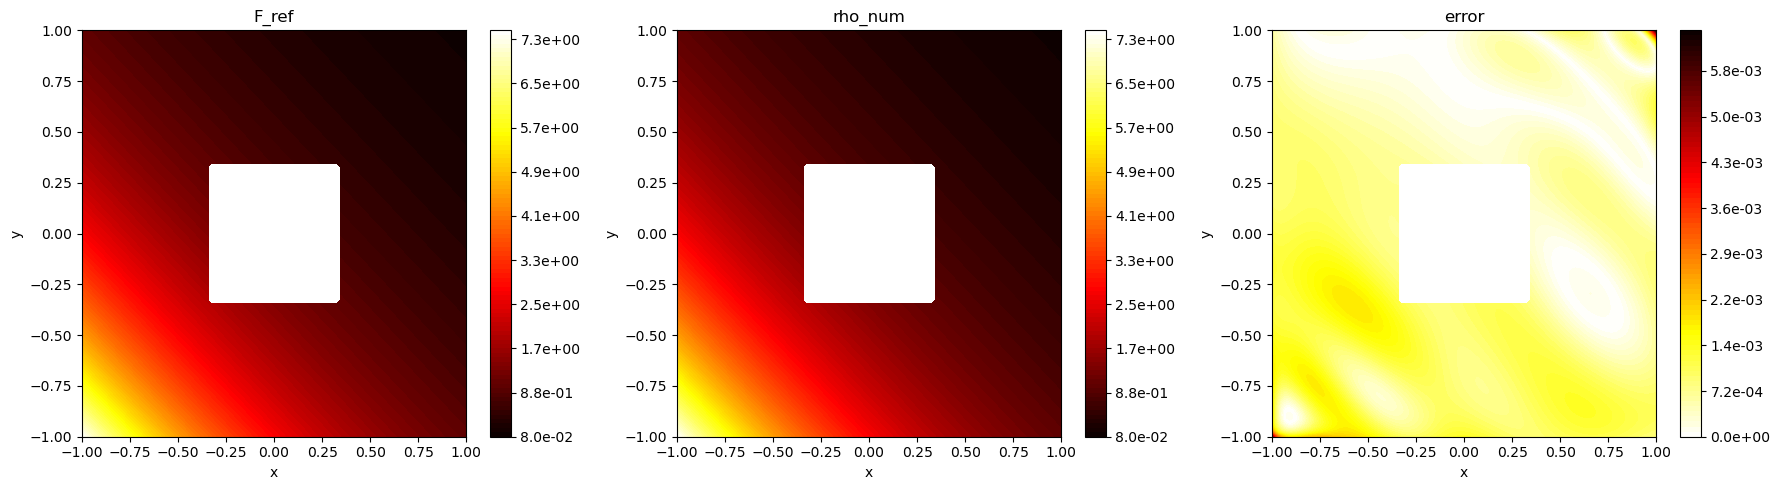

In [38]:
import matplotlib.pyplot as plt

# 假设 mesh_x, mesh_y 为 1D numpy 数组，r_bar, F_ref 为 1D 或 2D
Nx = len(mesh_x)
Ny = len(mesh_y)
X, Y = np.meshgrid(mesh_x, mesh_y, indexing="ij")

# 自动 reshape r_bar, F_ref
rho_app_plot = F_app.reshape(numx, numy)
F_ref_plot = F_ref.reshape(numx, numy)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.contourf(X, Y, F_ref_plot, 100, cmap="hot")
plt.colorbar(format="%.1e")
plt.title("F_ref")
plt.xlabel("x")
plt.ylabel("y")

plt.subplot(1, 3, 2)
plt.contourf(X, Y, rho_app_plot, 100, cmap="hot")
plt.colorbar(format="%.1e")
plt.title("rho_num")
plt.xlabel("x")
plt.ylabel("y")

plt.subplot(1, 3, 3)
plt.contourf(X, Y, np.abs(rho_app_plot - F_ref_plot), 100, cmap="hot_r")
plt.colorbar(format="%.1e")
plt.title("error")
plt.xlabel("x")
plt.ylabel("y")

plt.tight_layout()
plt.show()

Relative L2 Error at x=-1: 4.461e-03


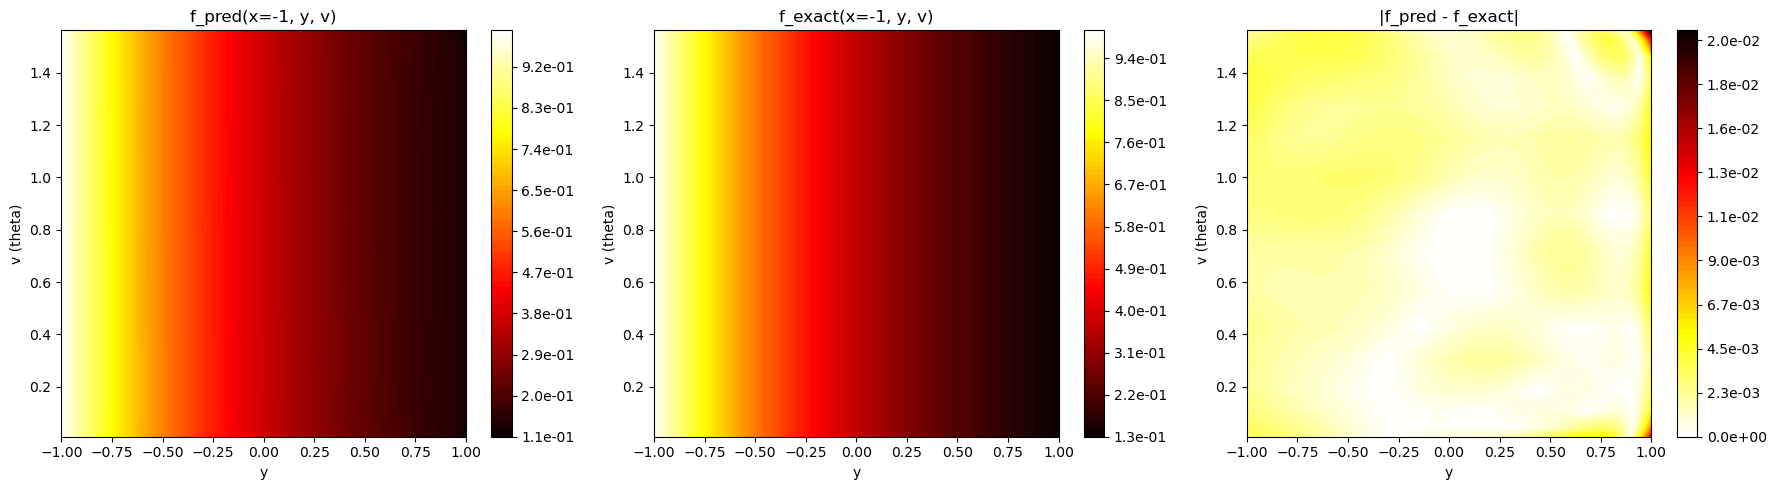

In [39]:
# 直接生成 (x=-1, y, v) 数据集，预测 f = kn * j2 + r2
import matplotlib.pyplot as plt

# 生成 y, v 网格
numy = 100
numv = num_vquads  # 保持与训练一致
x_val = 1

y_vals = np.linspace(-1, 1, numy)
v_vals = vquads  # 使用已有的 vquads

Y, V = np.meshgrid(y_vals, v_vals, indexing="ij")
X = np.full_like(Y, x_val)

# 转为 torch tensor，放到 mesh_xx.device 上
device_ = mesh_xx.device if "mesh_xx" in locals() else torch.device("cpu")
x_in = torch.tensor(X.reshape(-1, 1), dtype=torch.float32, device=device_)
y_in = torch.tensor(Y.reshape(-1, 1), dtype=torch.float32, device=device_)
v_in = torch.tensor(V.reshape(-1, 1), dtype=torch.float32, device=device_)

# 确保网络在 device_ 上
j2_nn = j2_nn.to(device_)
r2_nn = r2_nn.to(device_)

with torch.no_grad():
    j2_val = rte_constraint.model_j2(j2_nn, (x_in, y_in, v_in))
    r2_val = rte_constraint.model_r2(r2_nn, (x_in, y_in, v_in))
    f_val = -kn * j2_val + r2_val
    f_val = f_val.cpu().numpy().reshape(numy, numv)
    f_ex = np.exp(-X - Y).reshape(numy, numv)

err_bdy = np.linalg.norm(f_val - f_ex) / np.linalg.norm(f_ex)
print(f"Relative L2 Error at x=-1: {err_bdy:.3e}")

# 可视化 f_val, f_ex, 误差
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.contourf(y_vals, v_vals, f_val.T, 100, cmap="hot")
plt.colorbar(format="%.1e")
plt.xlabel("y")
plt.ylabel("v (theta)")
plt.title("f_pred(x=-1, y, v)")

plt.subplot(1, 3, 2)
plt.contourf(y_vals, v_vals, f_ex.T, 100, cmap="hot")
plt.colorbar(format="%.1e")
plt.xlabel("y")
plt.ylabel("v (theta)")
plt.title("f_exact(x=-1, y, v)")

plt.subplot(1, 3, 3)
plt.contourf(y_vals, v_vals, np.abs(f_val - f_ex).T, 100, cmap="hot_r")
plt.colorbar(format="%.1e")
plt.xlabel("y")
plt.ylabel("v (theta)")
plt.title("|f_pred - f_exact|")

plt.tight_layout()
plt.show()